fatal: destination path 'GreenPulse' already exists and is not an empty directory.
/content/GreenPulse
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Using Colab cache for faster access to the 'plant-disease-detection' dataset.
/kaggle/input/plantvillage-dataset
/kaggle/input/plant-disease-detection
Class mapping defined for 7 unified target classes
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Using Colab cache for faster access to the 'plant-disease-detection' dataset.
Using Colab cache for faster access to the 'cacao-diseases' dataset.
Cleaned dataset! Removed 5484 duplicate images.

Clean Unified Dataset Structure:
  └─ Maize_Northern_Leaf_Blight: 2116 unique images
  └─ Tomato_Late_Blight: 1901 unique images
  └─ Tomato_Healthy: 1585 unique images
  └─ Maize_Healthy: 2084 unique images
  └─ Cocoa_Healthy: 3344 unique images
  └─ Cocoa_Pod_Borer: 103 unique images
  └─ Cocoa_Black_Pod_Rot: 943 unique images
  └─ Tomato_Leaf_M

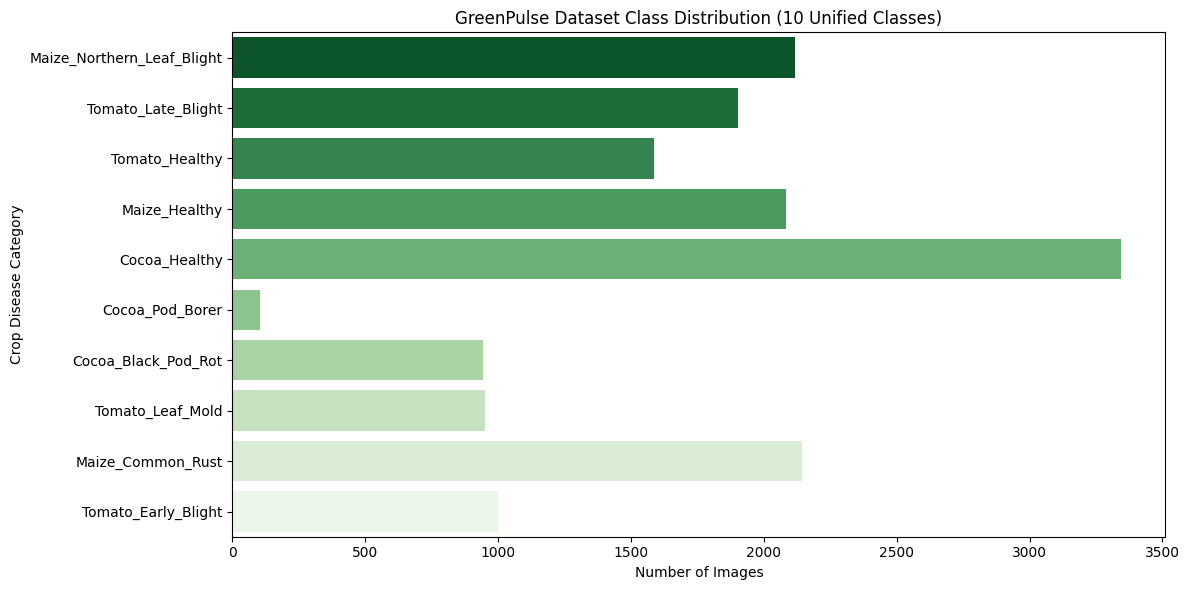

In [1]:
!git clone https://github.com/KekeliIsHere/GreenPulse.git
%cd GreenPulse
%run notebooks/00_data_exploration_and_cleaning.ipynb

In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [3]:
class GreenPulseCustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(GreenPulseCustomCNN, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(
            128 * 28 * 28,
            256
        )

        self.fc2 = nn.Linear(
            256,
            num_classes
        )

    def forward(self, x):

        x = self.pool(
            F.relu(
                self.bn1(
                    self.conv1(x)
                )
            )
        )

        x = self.pool(
            F.relu(
                self.bn2(
                    self.conv2(x)
                )
            )
        )

        x = self.pool(
            F.relu(
                self.bn3(
                    self.conv3(x)
                )
            )
        )

        x = torch.flatten(x, 1)

        x = self.dropout(
            F.relu(
                self.fc1(x)
            )
        )

        x = self.fc2(x)

        return x

In [4]:
class_names = [
    "Cocoa_Black_Pod_Rot",
    "Cocoa_Healthy",
    "Cocoa_Pod_Borer",
    "Maize_Common_Rust",
    "Maize_Healthy",
    "Maize_Northern_Leaf_Blight",
    "Tomato_Early_Blight",
    "Tomato_Healthy",
    "Tomato_Late_Blight",
    "Tomato_Leaf_Mold"
]

In [5]:
import zipfile

with zipfile.ZipFile(
    "models/custom_greenpulse_model.pth.zip",
    "r"
) as zip_ref:

    zip_ref.extractall("models")

print(os.listdir("models"))

['crop_disease_model.pth', 'custom_greenpulse_model.pth.zip', 'custom_greenpulse_model']


In [6]:
custom_model = GreenPulseCustomCNN(
    num_classes=10
).to(device)

checkpoint = torch.load(
    "models/custom_greenpulse_model.pth.zip",
    map_location=device
)

custom_model.load_state_dict(checkpoint)

custom_model.eval()

print("Custom GreenPulse model loaded successfully!")

Custom GreenPulse model loaded successfully!


In [7]:
test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
import os

for root, dirs, files in os.walk("/content/GreenPulse"):
    for file in files:
        if file.endswith(".ipynb"):
            print(os.path.join(root, file))

/content/GreenPulse/evaluation_second_model.ipynb
/content/GreenPulse/notebooks/evaluation.ipynb
/content/GreenPulse/notebooks/01_personal_model_training.ipynb
/content/GreenPulse/notebooks/01_model_training.ipynb
/content/GreenPulse/notebooks/00_data_exploration_and_cleaning.ipynb
/content/GreenPulse/notebooks/model_processing.ipynb


In [9]:
from pathlib import Path

dataset_path = Path("/content/clean_crop_dataset")

print("Dataset exists:", dataset_path.exists())

if dataset_path.exists():
    print("Classes:", [x.name for x in dataset_path.iterdir() if x.is_dir()])

Dataset exists: True
Classes: ['Maize_Northern_Leaf_Blight', 'Tomato_Late_Blight', 'Tomato_Healthy', 'Maize_Healthy', 'Cocoa_Healthy', 'Cocoa_Pod_Borer', 'Cocoa_Black_Pod_Rot', 'Tomato_Leaf_Mold', 'Maize_Common_Rust', 'Tomato_Early_Blight']


In [10]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

full_dataset = ImageFolder(
    root=dataset_path,
    transform=test_transform
)

total_size = len(full_dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(0)

train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print("Total:", total_size)
print("Train:", len(train_ds))
print("Validation:", len(val_ds))
print("Test:", len(test_ds))

Total: 16172
Train: 11320
Validation: 2425
Test: 2427


In [11]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Test images:", len(test_ds))
print("Test batches:", len(test_loader))

Test images: 2427
Test batches: 76


In [12]:
custom_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = custom_model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )
        all_labels.extend(
            labels.cpu().numpy()
        )

print("Evaluation complete.")
print("Predictions:", len(all_predictions))
print("Labels:", len(all_labels))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Evaluation complete.
Predictions: 2427
Labels: 2427


In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 93.16%


In [14]:
from sklearn.metrics import classification_report

class_names = test_ds.dataset.classes

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

                            precision    recall  f1-score   support

       Cocoa_Black_Pod_Rot     0.9000    0.5040    0.6462       125
             Cocoa_Healthy     0.8744    0.9888    0.9281       535
           Cocoa_Pod_Borer     0.0000    0.0000    0.0000        15
         Maize_Common_Rust     0.9936    0.9873    0.9904       315
             Maize_Healthy     0.9933    1.0000    0.9966       296
Maize_Northern_Leaf_Blight     0.9682    0.9911    0.9795       338
       Tomato_Early_Blight     0.8636    0.7252    0.7884       131
            Tomato_Healthy     0.9916    1.0000    0.9958       236
        Tomato_Late_Blight     0.8805    0.8866    0.8836       291
          Tomato_Leaf_Mold     0.8961    0.9517    0.9231       145

                  accuracy                         0.9316      2427
                 macro avg     0.8361    0.8035    0.8132      2427
              weighted avg     0.9262    0.9316    0.9248      2427



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


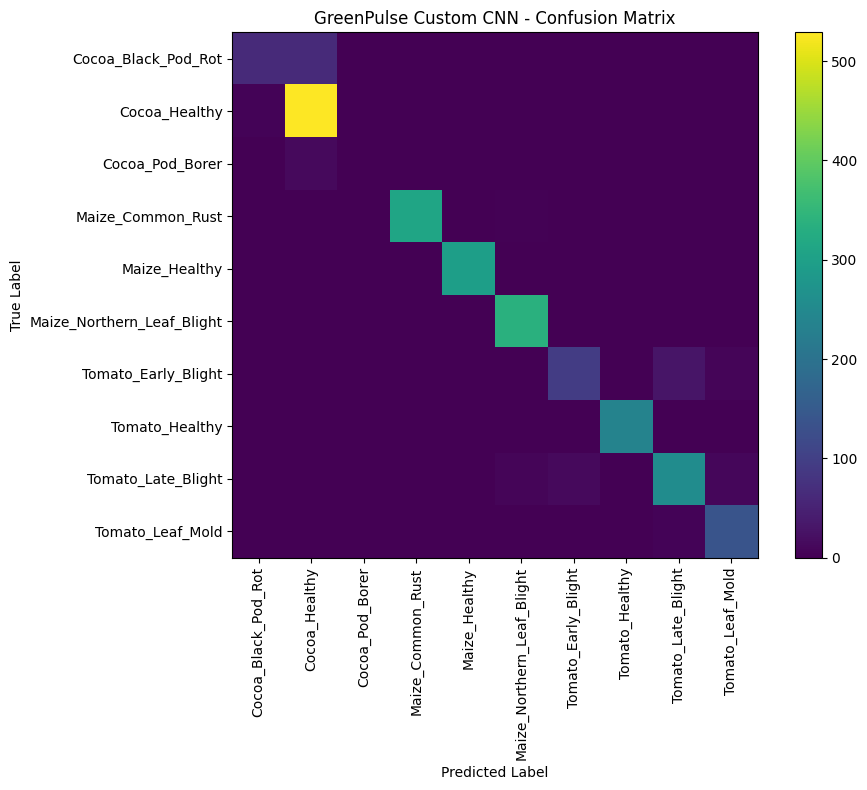

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("GreenPulse Custom CNN - Confusion Matrix")

plt.tight_layout()
plt.show()

The custom GreenPulse CNN achieved a test accuracy of 93.16% across 2,427 test images. The model demonstrated strong performance on most maize and tomato classes, with particularly high F1-scores for Maize Healthy (99.66%), Maize Common Rust (99.04%), Maize Northern Leaf Blight (97.95%), and Tomato Healthy (99.58%). However, performance was substantially weaker for Cocoa Pod Borer, which achieved 0% precision, recall, and F1-score, and Cocoa Black Pod Rot, which achieved 64.62% F1-score. The lower performance on these cocoa disease classes is likely associated with their relatively small representation in the test set, particularly Cocoa Pod Borer with only 15 samples.

In [16]:
from sklearn.metrics import classification_report

class_names = [
    "Cocoa_Black_Pod_Rot",
    "Cocoa_Healthy",
    "Cocoa_Pod_Borer",
    "Maize_Common_Rust",
    "Maize_Healthy",
    "Maize_Northern_Leaf_Blight",
    "Tomato_Early_Blight",
    "Tomato_Healthy",
    "Tomato_Late_Blight",
    "Tomato_Leaf_Mold"
]

report = classification_report(
    all_labels,
    all_predictions,
    labels=list(range(10)),
    target_names=class_names,
    zero_division=0
)

print(report)

                            precision    recall  f1-score   support

       Cocoa_Black_Pod_Rot       0.90      0.50      0.65       125
             Cocoa_Healthy       0.87      0.99      0.93       535
           Cocoa_Pod_Borer       0.00      0.00      0.00        15
         Maize_Common_Rust       0.99      0.99      0.99       315
             Maize_Healthy       0.99      1.00      1.00       296
Maize_Northern_Leaf_Blight       0.97      0.99      0.98       338
       Tomato_Early_Blight       0.86      0.73      0.79       131
            Tomato_Healthy       0.99      1.00      1.00       236
        Tomato_Late_Blight       0.88      0.89      0.88       291
          Tomato_Leaf_Mold       0.90      0.95      0.92       145

                  accuracy                           0.93      2427
                 macro avg       0.84      0.80      0.81      2427
              weighted avg       0.93      0.93      0.92      2427



<Figure size 1000x800 with 0 Axes>

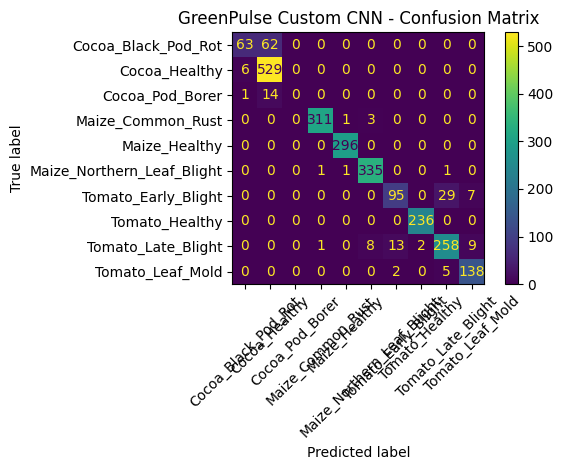

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=list(range(10))
)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    values_format="d"
)

plt.title("GreenPulse Custom CNN - Confusion Matrix")
plt.tight_layout()
plt.show()

In [18]:
import numpy as np

# Correct predictions for each class
correct = np.diag(cm)

# Total actual samples for each class
total = cm.sum(axis=1)

# Per-class accuracy
class_accuracy = correct / total

print("Per-Class Accuracy:\n")

for name, acc in zip(class_names, class_accuracy):
    print(f"{name:30s}: {acc * 100:.2f}%")

Per-Class Accuracy:

Cocoa_Black_Pod_Rot           : 50.40%
Cocoa_Healthy                 : 98.88%
Cocoa_Pod_Borer               : 0.00%
Maize_Common_Rust             : 98.73%
Maize_Healthy                 : 100.00%
Maize_Northern_Leaf_Blight    : 99.11%
Tomato_Early_Blight           : 72.52%
Tomato_Healthy                : 100.00%
Tomato_Late_Blight            : 88.66%
Tomato_Leaf_Mold              : 95.17%


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision_macro = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

precision_weighted = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print("===== GreenPulse Custom CNN Evaluation =====")
print(f"Accuracy:           {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Macro Precision:    {precision_macro:.4f}")
print(f"Macro Recall:       {recall_macro:.4f}")
print(f"Macro F1:           {f1_macro:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall:    {recall_weighted:.4f}")
print(f"Weighted F1:        {f1_weighted:.4f}")

===== GreenPulse Custom CNN Evaluation =====
Accuracy:           0.9316 (93.16%)
Macro Precision:    0.8361
Macro Recall:       0.8035
Macro F1:           0.8132
Weighted Precision: 0.9262
Weighted Recall:    0.9316
Weighted F1:        0.9248


In [23]:
from sklearn.metrics import classification_report

class_names = full_dataset.classes

report = classification_report(
    all_labels,
    all_predictions,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0
)

print("===== GreenPulse Custom CNN Classification Report =====")
print(report)

===== GreenPulse Custom CNN Classification Report =====
                            precision    recall  f1-score   support

       Cocoa_Black_Pod_Rot       0.90      0.50      0.65       125
             Cocoa_Healthy       0.87      0.99      0.93       535
           Cocoa_Pod_Borer       0.00      0.00      0.00        15
         Maize_Common_Rust       0.99      0.99      0.99       315
             Maize_Healthy       0.99      1.00      1.00       296
Maize_Northern_Leaf_Blight       0.97      0.99      0.98       338
       Tomato_Early_Blight       0.86      0.73      0.79       131
            Tomato_Healthy       0.99      1.00      1.00       236
        Tomato_Late_Blight       0.88      0.89      0.88       291
          Tomato_Leaf_Mold       0.90      0.95      0.92       145

                  accuracy                           0.93      2427
                 macro avg       0.84      0.80      0.81      2427
              weighted avg       0.93      0.93      0.92 

In [26]:
evaluation_results = {
    "test_accuracy": accuracy,
    "macro_precision": precision_macro,
    "macro_recall": recall_macro,
    "macro_f1": f1_macro,
    "weighted_precision": precision_weighted,
    "weighted_recall": recall_weighted,
    "weighted_f1": f1_weighted
}

print("===== Final Evaluation Results =====")

for metric, value in evaluation_results.items():
    print(f"{metric}: {value:.4f}")

===== Final Evaluation Results =====
test_accuracy: 0.9316
macro_precision: 0.8361
macro_recall: 0.8035
macro_f1: 0.8132
weighted_precision: 0.9262
weighted_recall: 0.9316
weighted_f1: 0.9248


In [27]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels,
    all_predictions,
    labels=list(range(len(class_names))),
    zero_division=0
)

print("===== Lowest Performing Classes =====")

for i in sorted(range(len(class_names)), key=lambda x: f1[x]):
    print(
        f"{class_names[i]:35s} "
        f"F1: {f1[i]:.2%} | "
        f"Precision: {precision[i]:.2%} | "
        f"Recall: {recall[i]:.2%} | "
        f"Support: {support[i]}"
    )

===== Lowest Performing Classes =====
Cocoa_Pod_Borer                     F1: 0.00% | Precision: 0.00% | Recall: 0.00% | Support: 15
Cocoa_Black_Pod_Rot                 F1: 64.62% | Precision: 90.00% | Recall: 50.40% | Support: 125
Tomato_Early_Blight                 F1: 78.84% | Precision: 86.36% | Recall: 72.52% | Support: 131
Tomato_Late_Blight                  F1: 88.36% | Precision: 88.05% | Recall: 88.66% | Support: 291
Tomato_Leaf_Mold                    F1: 92.31% | Precision: 89.61% | Recall: 95.17% | Support: 145
Cocoa_Healthy                       F1: 92.81% | Precision: 87.44% | Recall: 98.88% | Support: 535
Maize_Northern_Leaf_Blight          F1: 97.95% | Precision: 96.82% | Recall: 99.11% | Support: 338
Maize_Common_Rust                   F1: 99.04% | Precision: 99.36% | Recall: 98.73% | Support: 315
Tomato_Healthy                      F1: 99.58% | Precision: 99.16% | Recall: 100.00% | Support: 236
Maize_Healthy                       F1: 99.66% | Precision: 99.33% | Recal